In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
tr = pd.read_csv("data/KDDTrain+.txt", header=None)
print(tr.shape)
print(tr.dtypes.value_counts())
tr.head()

(125973, 43)
int64      24
float64    15
str         4
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
COLS = [41, 42]
y_tr = (tr[41] != "normal").astype(int)      # 1 = attack
X_tr = tr.drop(columns=COLS)

print("Training distribution:")
print(y_tr.value_counts(normalize=True).round(3))
print("\nAttack types:", tr[41].nunique() - 1)
print(tr[41].value_counts().head(8))

Training distribution:
41
0    0.535
1    0.465
Name: proportion, dtype: float64

Attack types: 22
41
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
smurf         2646
nmap          1493
back           956
Name: count, dtype: int64


In [6]:
for c in [1, 2, 3]:
    print(f"Column {c}: {tr[c].nunique()} values")
    print(tr[c].value_counts().head(11).to_string())
    print()

Column 1: 3 values
1
tcp     102689
udp      14993
icmp      8291

Column 2: 70 values
2
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
ftp          1754

Column 3: 11 values
3
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46



In [7]:
s = tr.groupby(2).agg(n=(41, "size"), attack=(41, lambda x: (x != "normal").mean()))
s = s.sort_values("n", ascending=False)

print("Top 10:")
print(s.head(10).round(3).to_string())
print("\nRare (< 500 rows):")
rare = s[s["n"] < 500]
print(f"{len(rare)} services | total rows {rare['n'].sum():,}")
print(f"Combined attack rate: {(rare['n']*rare['attack']).sum()/rare['n'].sum():.3f}")
print("\nTop 8 attack rates among the rare:")
print(rare.sort_values("attack", ascending=False).head(8).round(3).to_string())

Top 10:
              n  attack
2                      
http      40338   0.057
private   21853   0.955
domain_u   9043   0.001
smtp       7313   0.039
ftp_data   6860   0.273
eco_i      4586   0.892
other      4359   0.403
ecr_i      3077   0.938
telnet     2353   0.610
finger     1767   0.692

Rare (< 500 rows):
38 services | total rows 9,082
Combined attack rate: 0.929

Top 8 attack rates among the rare:
             n  attack
2                     
efs        485     1.0
systat     477     1.0
link       475     1.0
exec       474     1.0
hostnames  460     1.0
name       451     1.0
mtp        439     1.0
echo       434     1.0


In [8]:
from sklearn.model_selection import train_test_split

y = (tr[41] != "normal").astype(int)
X = tr.drop(columns=[41, 42])

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_tr.shape, X_val.shape)

(100778, 41) (25195, 41)


In [9]:
TOP = 10
top_svc  = X_tr[2].value_counts().head(TOP).index.tolist()
freq_map = X_tr[2].value_counts().to_dict()

def encode(d):
    d = d.copy()
    d["svc_freq"]  = d[2].map(freq_map).fillna(0)
    d["svc_group"] = d[2].where(d[2].isin(top_svc), "rare")
    d = d.drop(columns=[2])
    d = pd.get_dummies(d, columns=[1, 3, "svc_group"], dtype=int)
    d.columns = d.columns.astype(str)
    return d

E_tr  = encode(X_tr)
E_val = encode(X_val).reindex(columns=E_tr.columns, fill_value=0)

print(E_tr.shape, E_val.shape)
print("Columns match:", list(E_tr.columns) == list(E_val.columns))

(100778, 64) (25195, 64)
Columns match: True


In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

clf = HistGradientBoostingClassifier(random_state=42)
clf.fit(E_tr, y_tr)
p = clf.predict(E_val)

print(confusion_matrix(y_val, p))
print(classification_report(y_val, p, digits=4))

[[13462     7]
 [    9 11717]]
              precision    recall  f1-score   support

           0     0.9993    0.9995    0.9994     13469
           1     0.9994    0.9992    0.9993     11726

    accuracy                         0.9994     25195
   macro avg     0.9994    0.9994    0.9994     25195
weighted avg     0.9994    0.9994    0.9994     25195



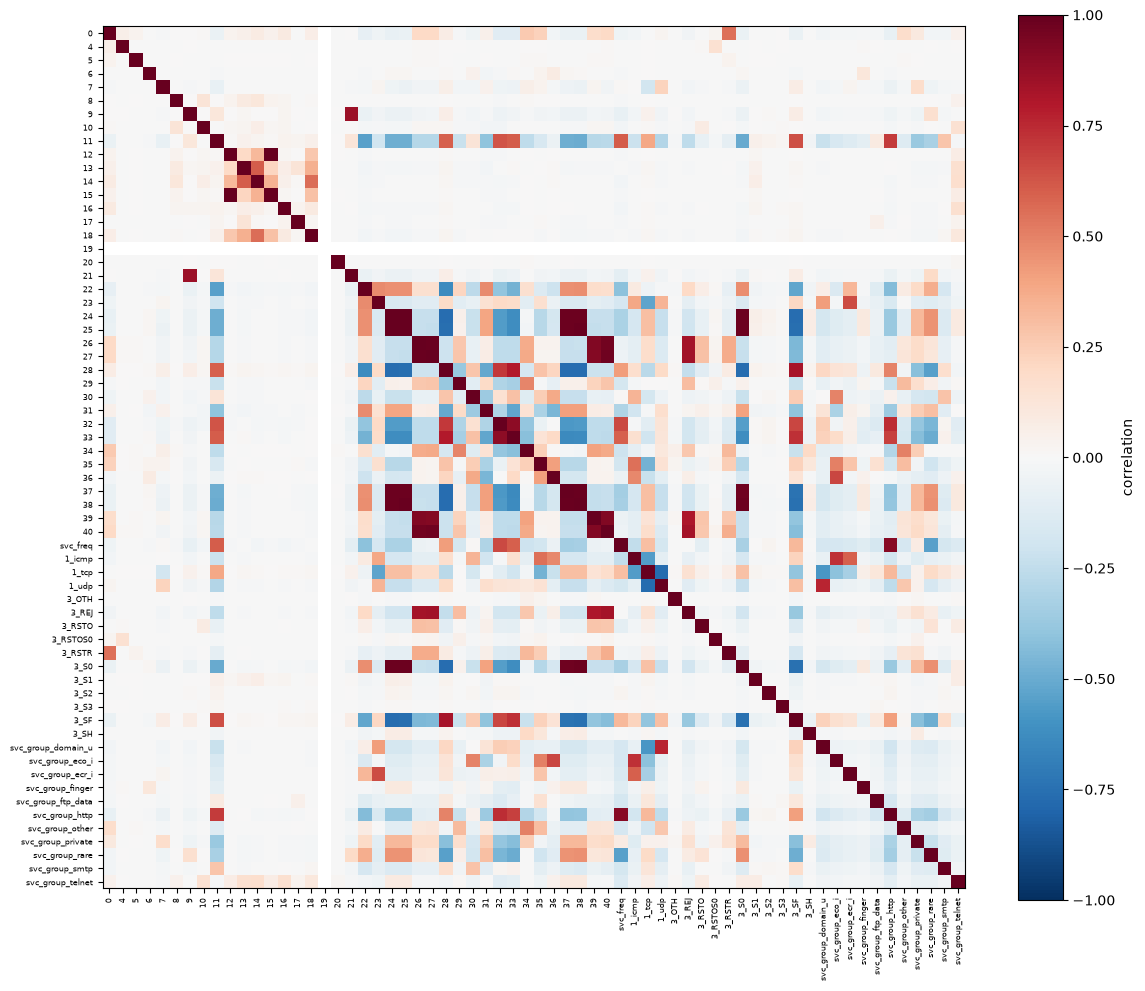

In [11]:
C = E_tr.corr()

plt.figure(figsize=(12, 10))
plt.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(C)), C.columns, rotation=90, fontsize=6)
plt.yticks(range(len(C)), C.columns, fontsize=6)
plt.tight_layout()

In [12]:
print(E_tr.nunique().sort_values().head(10))

19                  1
6                   2
13                  2
11                  2
20                  2
21                  2
svc_group_eco_i     2
svc_group_telnet    2
svc_group_ecr_i     2
svc_group_smtp      2
dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

E_tr  = E_tr.drop(columns=["19"])
E_val = E_val.drop(columns=["19"])

sc = StandardScaler().fit(E_tr)
Z_tr, Z_val = sc.transform(E_tr), sc.transform(E_val)

cum = np.cumsum(PCA().fit(Z_tr).explained_variance_ratio_)
for k in [2, 5, 10, 15, 20, 25, 30, 40]:
    print(f"{k:>3} components → {cum[k-1]*100:.1f}%")
print("\nFor 95%:", np.argmax(cum >= .95) + 1, "components out of", len(cum))

  2 components → 25.4%
  5 components → 41.6%
 10 components → 56.2%
 15 components → 66.1%
 20 components → 74.5%
 25 components → 82.4%
 30 components → 89.6%
 40 components → 97.7%

For 95%: 36 components out of 63


In [14]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

N_tr = E_tr[y_tr == 0]          # normal only
print("Training:", N_tr.shape)

for c in [0.001, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    iso = IsolationForest(contamination=c, random_state=42, n_jobs=-1)
    iso.fit(N_tr)
    p = (iso.predict(E_val) == -1).astype(int)      # ‎−1‎ = anomaly
    tn, fp, fn, tp = confusion_matrix(y_val, p).ravel()
    print(f"c={c:<6} | caught {tp:>5}/{tp+fn} | missed {fn:>5}"
          f" | false {fp:>5} | recall {tp/(tp+fn):.3f} | precision {tp/(tp+fp):.3f}")

Training: (53874, 63)
c=0.001  | caught  6798/11726 | missed  4928 | false    14 | recall 0.580 | precision 0.998
c=0.01   | caught  9337/11726 | missed  2389 | false   132 | recall 0.796 | precision 0.986
c=0.02   | caught  9482/11726 | missed  2244 | false   234 | recall 0.809 | precision 0.976
c=0.05   | caught 10341/11726 | missed  1385 | false   619 | recall 0.882 | precision 0.944
c=0.1    | caught 10937/11726 | missed   789 | false  1363 | recall 0.933 | precision 0.889
c=0.15   | caught 11266/11726 | missed   460 | false  2024 | recall 0.961 | precision 0.848
c=0.2    | caught 11470/11726 | missed   256 | false  2685 | recall 0.978 | precision 0.810
c=0.25   | caught 11546/11726 | missed   180 | false  3365 | recall 0.985 | precision 0.774
c=0.3    | caught 11634/11726 | missed    92 | false  4041 | recall 0.992 | precision 0.742


In [15]:
clf = HistGradientBoostingClassifier(random_state=42).fit(E_tr, y_tr)
print("val:", (clf.predict(E_val) == y_val).mean().round(4))

val: 0.9994


In [16]:
te = pd.read_csv("data/KDDTest+.txt", header=None)

y_te = (te[41] != "normal").astype(int)
X_te = te.drop(columns=[41, 42])
E_te = encode(X_te).reindex(columns=E_tr.columns, fill_value=0)

new = sorted(set(te[41].unique()) - set(tr[41].unique()))
print(f"New types: {len(new)}")
print(f"Their rows: {te[41].isin(new).sum():,} of {len(te):,}")
print(f"Attack rate: {y_te.mean():.3f}\n")

iso = IsolationForest(contamination=0.15, random_state=42, n_jobs=-1).fit(N_tr)

for name, p in [("classifier", clf.predict(E_te)),
                ("detector",  (iso.predict(E_te) == -1).astype(int))]:
    tn, fp, fn, tp = confusion_matrix(y_te, p).ravel()
    is_new = te[41].isin(new).values
    caught_new = ((p == 1) & is_new).sum()
    print(f"{name} | recall {tp/(tp+fn):.3f} | precision {tp/(tp+fp):.3f}"
          f" | false {fp} | new types caught {caught_new}/{is_new.sum()}")

New types: 17
Their rows: 3,750 of 22,544
Attack rate: 0.569

classifier | recall 0.648 | precision 0.968 | false 271 | new types caught 1288/3750
detector | recall 0.783 | precision 0.917 | false 912 | new types caught 2925/3750


In [17]:
p_clf = clf.predict(E_te)
p_iso = (iso.predict(E_te) == -1).astype(int)
both  = ((p_clf == 1) | (p_iso == 1)).astype(int)

tn, fp, fn, tp = confusion_matrix(y_te, both).ravel()
print(f"union | recall {tp/(tp+fn):.3f} | precision {tp/(tp+fp):.3f} | false {fp}")

union | recall 0.812 | precision 0.918 | false 932


In [18]:
att = tr[tr[41] != "normal"][41].value_counts()

print(f"Total attacks: {att.sum():,} | types: {len(att)}\n")
print(att.head(12).to_string())
print(f"\nTop 10 cover: {att.head(10).sum()/att.sum()*100:.1f}%")
print(f"Types under 100 rows: {(att < 100).sum()}, totalling {att[att < 100].sum()} rows")

Total attacks: 58,630 | types: 22

41
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30

Top 10 cover: 99.7%
Types under 100 rows: 12, totalling 175 rows


In [19]:
TOP9 = att.head(9).index.tolist()

atk_tr = tr[tr[41] != "normal"]
X9 = atk_tr.drop(columns=[41, 42])
y9 = atk_tr[41].where(atk_tr[41].isin(TOP9), "others")

X9_tr, X9_val, y9_tr, y9_val = train_test_split(
    X9, y9, test_size=0.2, random_state=42, stratify=y9)

E9_tr  = encode(X9_tr).drop(columns=["19"])
E9_val = encode(X9_val).reindex(columns=E9_tr.columns, fill_value=0)

m9 = HistGradientBoostingClassifier(random_state=42).fit(E9_tr, y9_tr)
p9 = m9.predict(E9_val)

print(classification_report(y9_val, p9, digits=3))

              precision    recall  f1-score   support

        back      0.967     0.932     0.949       191
     ipsweep      0.969     0.999     0.984       720
     neptune      1.000     1.000     1.000      8243
        nmap      0.997     0.990     0.993       299
      others      0.967     0.773     0.859        75
   portsweep      1.000     0.995     0.997       586
       satan      0.997     0.997     0.997       727
       smurf      1.000     1.000     1.000       529
    teardrop      1.000     1.000     1.000       178
 warezclient      0.989     1.000     0.994       178

    accuracy                          0.997     11726
   macro avg      0.989     0.969     0.977     11726
weighted avg      0.997     0.997     0.997     11726



In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sc9 = StandardScaler().fit(E9_tr)
Z9  = sc9.transform(E9_tr)

km = KMeans(n_clusters=10, random_state=42, n_init=10).fit(Z9)

ct = pd.crosstab(km.labels_, y9_tr.values)
print(ct.to_string())
print("\nPurity of each cluster:")
print((ct.max(axis=1) / ct.sum(axis=1)).round(3).to_string())

col_0  back  ipsweep  neptune  nmap  others  portsweep  satan  smurf  teardrop  warezclient
row_0                                                                                      
0         0        0    16339    34      16         46     30      0         0            0
1         0        0        0     0       2       1751      1      0         0            0
2         0        0        0   202       3          0   1149      0       714            0
3         0       20        0     6     110          1      7   2117         0            0
4         0        0        0     0       0        321   1674      0         0            0
5         0      358     5520     0      35        132      6      0         0            0
6         0     2488        0   771      67          2     18      0         0            0
7         0        0        0     0       5          0      1      0         0          243
8       765       13        0     0      63          3     20      0         0  

In [21]:
atk_te = te[y_te == 1]
E9_te = encode(atk_te.drop(columns=[41, 42])).reindex(columns=E9_tr.columns, fill_value=0)
y9_te = atk_te[41].where(atk_te[41].isin(TOP9), "others")

p9_te = m9.predict(E9_te)
print("Label accuracy:", (p9_te == y9_te.values).mean().round(4))
print()

is_new = atk_te[41].isin(new).values
print("On known types:", (p9_te[~is_new] == y9_te.values[~is_new]).mean().round(4))
print("On new types:", (p9_te[is_new] == y9_te.values[is_new]).mean().round(4))
print()
print("What it called the new types:")
print(pd.Series(p9_te[is_new]).value_counts().head(6).to_string())

Label accuracy: 0.5664

On known types: 0.7953
On new types: 0.0117

What it called the new types:
neptune        1474
warezclient     770
satan           674
nmap            543
portsweep       200
others           44


In [22]:
proba = m9.predict_proba(E9_te)
conf  = proba.max(axis=1)

for t in [0.0, 0.5, 0.7, 0.8, 0.9]:
    p = np.where(conf >= t, p9_te, "UNKNOWN")

    known = (p[~is_new] == y9_te.values[~is_new]).mean()
    abst_k = (p[~is_new] == "UNKNOWN").mean()
    abst_n = (p[is_new] == "UNKNOWN").mean()

    print(f"threshold {t} | known: correct {known:.3f} abstained {abst_k:.3f}"
          f" | new: abstained {abst_n:.3f}")

threshold 0.0 | known: correct 0.795 abstained 0.000 | new: abstained 0.000
threshold 0.5 | known: correct 0.792 abstained 0.022 | new: abstained 0.072
threshold 0.7 | known: correct 0.788 abstained 0.049 | new: abstained 0.303
threshold 0.8 | known: correct 0.787 abstained 0.053 | new: abstained 0.469
threshold 0.9 | known: correct 0.786 abstained 0.056 | new: abstained 0.565


In [23]:
te21 = pd.read_csv("data/KDDTest-21.txt", header=None)
y21  = (te21[41] != "normal").astype(int)
E21  = encode(te21.drop(columns=[41, 42])).reindex(columns=E_tr.columns, fill_value=0)

print(f"{len(te21):,} rows | attack rate {y21.mean():.3f}\n")

p_c = clf.predict(E21)
p_i = (iso.predict(E21) == -1).astype(int)
p_u = ((p_c == 1) | (p_i == 1)).astype(int)

for name, p in [("classifier", p_c), ("detector", p_i), ("union", p_u)]:
    tn, fp, fn, tp = confusion_matrix(y21, p).ravel()
    print(f"{name} | recall {tp/(tp+fn):.3f} | precision {tp/(tp+fp):.3f} | false {fp}")

11,850 rows | attack rate 0.818

classifier | recall 0.534 | precision 0.950 | false 271
detector | recall 0.712 | precision 0.893 | false 831
union | recall 0.751 | precision 0.895 | false 851


In [24]:
from sklearn.metrics import accuracy_score

for name, p in [("classifier", clf.predict(E_te)),
                ("detector",  (iso.predict(E_te) == -1).astype(int))]:
    print(f"{name} | accuracy {accuracy_score(y_te, p):.4f}")

both = ((clf.predict(E_te) == 1) | ((iso.predict(E_te) == -1))).astype(int)
print(f"union | accuracy {accuracy_score(y_te, both):.4f}")

classifier | accuracy 0.7875
detector | accuracy 0.8357
union | accuracy 0.8517


In [25]:
print("=== Binary classifier ===")
for nm, E, yy in [("train", E_tr, y_tr), ("val", E_val, y_val), ("test", E_te, y_te)]:
    p = clf.predict(E)
    print(f"{nm:<7} | acc {accuracy_score(yy, p):.4f}")

print("\n=== Multiclass classifier ===")
for nm, E, yy in [("train", E9_tr, y9_tr), ("val", E9_val, y9_val)]:
    print(f"{nm:<7} | acc {(m9.predict(E) == yy.values).mean():.4f}")

print("\n=== Detector ===")
for nm, E, yy in [("train(normal)", N_tr, pd.Series(0, index=N_tr.index)),
                  ("val", E_val, y_val), ("test", E_te, y_te)]:
    p = (iso.predict(E) == -1).astype(int)
    print(f"{nm:<14} | alarms on {p.mean():.3f}")

=== Binary classifier ===
train   | acc 0.9998
val     | acc 0.9994
test    | acc 0.7875

=== Multiclass classifier ===
train   | acc 0.9981
val     | acc 0.9967

=== Detector ===
train(normal)  | alarms on 0.150
val            | alarms on 0.527
test           | alarms on 0.486


In [26]:
p_bin  = ((clf.predict(E_te) == 1) | ((iso.predict(E_te) == -1))).astype(int)

E9_all = encode(te.drop(columns=[41, 42])).reindex(columns=E9_tr.columns, fill_value=0)
pr     = m9.predict_proba(E9_all)
nm     = np.where(pr.max(axis=1) >= 0.9, m9.predict(E9_all), "UNKNOWN")

out = np.where(p_bin == 0, "normal", nm)

res = pd.DataFrame({"decision": out, "truth": te[41].values,
                    "new": te[41].isin(new).values})

print(res["decision"].value_counts().head(8).to_string())
print("\nOf those labelled UNKNOWN:")
u = res[res["decision"] == "UNKNOWN"]
print(f"  count {len(u)} | actual attacks {(u['truth']!='normal').mean():.3f}"
      f" | new types {u['new'].mean():.3f}")

decision
normal         11190
neptune         5473
UNKNOWN         2174
satan           1080
warezclient      739
smurf            683
back             592
portsweep        170

Of those labelled UNKNOWN:
  count 2174 | actual attacks 0.732 | new types 0.617


In [27]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

sc = StandardScaler().fit(N_tr)          # fitted on normal only
Zn  = sc.transform(N_tr)
Zv  = sc.transform(E_val)

ae = MLPRegressor(hidden_layer_sizes=(16,), activation="relu",
                  max_iter=60, random_state=42, verbose=False)
ae.fit(Zn, Zn)                            # <- output = the input itself

err_n = ((ae.predict(Zn) - Zn) ** 2).mean(axis=1)
err_v = ((ae.predict(Zv) - Zv) ** 2).mean(axis=1)

print(f"train error (normal):     {err_n.mean():.4f}")
print(f"val error - normal:      {err_v[y_val==0].mean():.4f}")
print(f"val error - attack:       {err_v[y_val==1].mean():.4f}")
print(f"ratio (attack / normal):    {err_v[y_val==1].mean()/err_v[y_val==0].mean():.2f}×")

train error (normal):     0.3479
val error - normal:      0.4568
val error - attack:       32.5266
ratio (attack / normal):    71.21×


c:\Users\Asus\Desktop\eng\ai_control_projects\.venv313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

sc = StandardScaler().fit(N_tr)          # fitted on normal only
Zn  = sc.transform(N_tr)
Zv  = sc.transform(E_val)

ae = MLPRegressor(hidden_layer_sizes=(16,), activation="relu",
                  max_iter=300, random_state=42, verbose=False)
ae.fit(Zn, Zn)                            # <- output = the input itself

err_n = ((ae.predict(Zn) - Zn) ** 2).mean(axis=1)
err_v = ((ae.predict(Zv) - Zv) ** 2).mean(axis=1)

print(f"train error (normal):     {err_n.mean():.4f}")
print(f"val error - normal:      {err_v[y_val==0].mean():.4f}")
print(f"val error - attack:       {err_v[y_val==1].mean():.4f}")
print(f"ratio (attack / normal):    {err_v[y_val==1].mean()/err_v[y_val==0].mean():.2f}×")

train error (normal):     0.3469
val error - normal:      0.4614
val error - attack:       32.7642
ratio (attack / normal):    71.01×


In [29]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

sc = StandardScaler().fit(N_tr)          # fitted on normal only
Zn  = sc.transform(N_tr)
Zv  = sc.transform(E_val)

ae = MLPRegressor(hidden_layer_sizes=(32,16,32), activation="relu",
                  max_iter=300, random_state=42, verbose=False)
ae.fit(Zn, Zn)                            # <- output = the input itself

err_n = ((ae.predict(Zn) - Zn) ** 2).mean(axis=1)
err_v = ((ae.predict(Zv) - Zv) ** 2).mean(axis=1)

print(f"train error (normal):     {err_n.mean():.4f}")
print(f"val error - normal:      {err_v[y_val==0].mean():.4f}")
print(f"val error - attack:       {err_v[y_val==1].mean():.4f}")
print(f"ratio (attack / normal):    {err_v[y_val==1].mean()/err_v[y_val==0].mean():.2f}×")

train error (normal):     0.1250
val error - normal:      0.1327
val error - attack:       5.6121
ratio (attack / normal):    42.30×


In [30]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

sc = StandardScaler().fit(N_tr)          # fitted on normal only
Zn  = sc.transform(N_tr)
Zv  = sc.transform(E_val)

ae = MLPRegressor(hidden_layer_sizes=(32,8,32), activation="relu",
                  max_iter=300, random_state=42, verbose=False)
ae.fit(Zn, Zn)                            # <- output = the input itself

err_n = ((ae.predict(Zn) - Zn) ** 2).mean(axis=1)
err_v = ((ae.predict(Zv) - Zv) ** 2).mean(axis=1)

print(f"train error (normal):     {err_n.mean():.4f}")
print(f"val error - normal:      {err_v[y_val==0].mean():.4f}")
print(f"val error - attack:       {err_v[y_val==1].mean():.4f}")
print(f"ratio (attack / normal):    {err_v[y_val==1].mean()/err_v[y_val==0].mean():.2f}×")

train error (normal):     0.1403
val error - normal:      0.1685
val error - attack:       8.2222
ratio (attack / normal):    48.78×


In [31]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

sc = StandardScaler().fit(N_tr)          # fitted on normal only
Zn  = sc.transform(N_tr)
Zv  = sc.transform(E_val)

ae = MLPRegressor(hidden_layer_sizes=(32,16,8,16,32), activation="relu",
                  max_iter=300, random_state=42, verbose=False)
ae.fit(Zn, Zn)                            # <- output = the input itself

err_n = ((ae.predict(Zn) - Zn) ** 2).mean(axis=1)
err_v = ((ae.predict(Zv) - Zv) ** 2).mean(axis=1)

print(f"train error (normal):     {err_n.mean():.4f}")
print(f"val error - normal:      {err_v[y_val==0].mean():.4f}")
print(f"val error - attack:       {err_v[y_val==1].mean():.4f}")
print(f"ratio (attack / normal):    {err_v[y_val==1].mean()/err_v[y_val==0].mean():.2f}×")

train error (normal):     0.1830
val error - normal:      0.1997
val error - attack:       10.5968
ratio (attack / normal):    53.07×


In [32]:
def evaluate(model, scaler, name):
    Zn_ = scaler.transform(N_tr)
    Zv_ = scaler.transform(E_val)
    e_tr = ((model.predict(Zn_) - Zn_) ** 2).mean(axis=1)
    e_v  = ((model.predict(Zv_) - Zv_) ** 2).mean(axis=1)

    for q in [0.85, 0.90, 0.95, 0.99]:
        thr = np.quantile(e_tr, q)          # threshold from normal only
        p = (e_v > thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, p).ravel()
        print(f"{name} | q={q} | recall {tp/(tp+fn):.3f}"
              f" | precision {tp/(tp+fp):.3f} | false {fp}")
    print()

In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np

sc = StandardScaler().fit(N_tr)
Zn, Zv = sc.transform(N_tr), sc.transform(E_val)

def build(sizes, name):
    m = MLPRegressor(hidden_layer_sizes=sizes, activation="relu",
                     max_iter=300, random_state=42).fit(Zn, Zn)
    e_tr = ((m.predict(Zn) - Zn) ** 2).mean(axis=1)
    e_v  = ((m.predict(Zv) - Zv) ** 2).mean(axis=1)
    print(f"--- {name} | normal error {e_v[y_val==0].mean():.4f}"
          f" | attack {e_v[y_val==1].mean():.4f} ---")
    for q in [0.90, 0.95, 0.99]:
        p = (e_v > np.quantile(e_tr, q)).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, p).ravel()
        print(f"  q={q} | recall {tp/(tp+fn):.3f} | precision {tp/(tp+fp):.3f} | false {fp}")
    return m

ae16   = build((16,),        "shallow 16")
ae_dp  = build((32, 16, 32), "deep 32-16-32")

--- shallow 16 | normal error 0.4614 | attack 32.7642 ---
  q=0.9 | recall 0.959 | precision 0.892 | false 1362
  q=0.95 | recall 0.871 | precision 0.938 | false 680
  q=0.99 | recall 0.504 | precision 0.976 | false 148
--- deep 32-16-32 | normal error 0.1327 | attack 5.6121 ---
  q=0.9 | recall 0.949 | precision 0.894 | false 1326
  q=0.95 | recall 0.910 | precision 0.939 | false 698
  q=0.99 | recall 0.800 | precision 0.984 | false 151


In [34]:
Zt   = sc.transform(E_te)
e_tr = ((ae_dp.predict(Zn) - Zn) ** 2).mean(axis=1)
e_t  = ((ae_dp.predict(Zt) - Zt) ** 2).mean(axis=1)

p = (e_t > np.quantile(e_tr, 0.95)).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, p).ravel()

is_new = te[41].isin(new).values
print(f"Autoencoder q=0.95 | recall {tp/(tp+fn):.3f} | precision {tp/(tp+fp):.3f}"
      f" | false {fp} | new {((p==1)&is_new).sum()}/{is_new.sum()}")

Autoencoder q=0.95 | recall 0.780 | precision 0.920 | false 869 | new 2808/3750
